# Importing Libraries and functions

In [1]:
import pandas as pd
import numpy as np

# To save and load our models
import pickle

# To plot 
import matplotlib.pyplot as plt
import seaborn  as sns

# To training the model
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble        import RandomForestClassifier
from xgboost import XGBClassifier

# Explainability
import shap
from sklearn.inspection import permutation_importance

# Fairlearn 
from fairlearn.reductions import EqualizedOdds, ExponentiatedGradient
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import demographic_parity_difference, demographic_parity_ratio
from fairlearn.metrics import equalized_odds_difference,  equalized_odds_ratio
from fairlearn.metrics import selection_rate, true_negative_rate, true_positive_rate, false_positive_rate, false_negative_rate
from fairlearn.metrics import MetricFrame

# Personalized functions
from functions import compute_metrics, fpr, fnr, tmo

# Importing the data

In [2]:
df_trainval = pd.read_csv('CSV_TRAIN.csv', sep = ";")
df_test     = pd.read_csv('CSV_TEST.csv',  sep = ";")

df_trainval['TARGET'] = 1 - df_trainval["DEFAULT"]
df_test['TARGET']     = 1 - df_test["DEFAULT"]

In [3]:
df_trainval_nonulls = df_trainval.dropna().reset_index(drop=True)
df_test_nonulls     = df_test.dropna().reset_index(drop=True)

In [4]:
print(f"After dropping {df_trainval.shape[0] - df_trainval_nonulls.shape[0]} instances with some nulls, the training set has {df_trainval_nonulls.shape[0]} observations")
print(f"After dropping {df_test.shape[0]     - df_test_nonulls.shape[0]} instances with some nulls, the test set has {df_test_nonulls.shape[0]} observations")

After dropping 25 instances with some nulls, the training set has 20029 observations
After dropping 10 instances with some nulls, the test set has 5726 observations


# Train test split

In [5]:
X_trainval   = df_trainval_nonulls.drop(['DEFAULT','TARGET'], axis = 1)
Y_trainval   = df_trainval_nonulls['TARGET']

X_train, X_val, Y_train, Y_val = train_test_split(X_trainval, Y_trainval, test_size = 0.25, random_state = 1)

X_test   = df_test_nonulls.drop(['DEFAULT','TARGET'], axis = 1)
Y_test   = df_test_nonulls['TARGET']


PF1_train = X_train['PF1']
PF2_train = X_train['PF2']

PF1_val   = X_val['PF1']
PF2_val   = X_val['PF2']

PF1_test  = X_test['PF1']
PF2_test = X_test['PF2']

X_train = X_train.drop(['PF1', 'PF2'], axis = 1)
X_val   = X_val.drop(['PF1', 'PF2'], axis = 1)
X_test  = X_test.drop(['PF1', 'PF2'], axis = 1)

In [6]:
print(f" The dataset we will use for training   has {X_train.shape[0]} observations and {X_train.shape[1]} features.")
print(f" The dataset we will use for validation has {X_val.shape[0]} observations and {X_train.shape[1]} features.")
print(f" The dataset we will use for test       has {X_test.shape[0]} observations and {X_test.shape[1]} features.")

 The dataset we will use for training   has 15021 observations and 16 features.
 The dataset we will use for validation has 5008 observations and 16 features.
 The dataset we will use for test       has 5726 observations and 16 features.


# In the search of the optimal delta

In this notebook we will be applying the reweighing technique. It consists in assigning a higher weight to some instances during the training of the model, depending on our goal. As we want to increase the recall the model has on the protected group of the protected feature 2, we will be assigning a higher weight to good repayer belonging to that class.

In [7]:
param_grid = {
    'max_depth': [2, 4],
    'learning_rate': [0.01, 0.025, 0.05],
    'n_estimators': [1000],
    'gamma': [10, 25],
    'subsample': [0.8],
    'colsample_bytree': [0.75],
    'min_child_weight': [8, 32],
    'early_stopping_rounds': [50]}
   

As we will have to optimize the hyperparameters for 20 deltas, we have reduced a bit the space of hyperparameters leveraging some of the insights we got from the optimization of hyperparameters in the base model and the unaware model. 

In [8]:
metrics = {
    "Default_rate": tmo,
    "Accuracy": accuracy_score,
    "Precision": precision_score,
    "Recall": recall_score,
    "Selection_rate": selection_rate,
    "FPR": false_positive_rate,
    "FNR": false_negative_rate,
    "Specificity": true_negative_rate
}


In [9]:
deltas = np.linspace(0.75, 2.5, 20)
thresholds = np.linspace(0.7, 1, 250)

columns_summary = ["Delta", "Threshold", "Default_Rate", "Accuracy", 
                    "Precision", "Recall", "Selection_Rate",
                 "FPR", "FNR", "Specificity"]

rows_summary = []
best_params_by_delta = {}

for delta in deltas:
    
    
    # Example: manually boost group with lower recall
    weights = np.ones(len(Y_train))

    # As group 1 in the protected feature 2 have lower recall, we will increase the weight of positive sample of this group
    weights[(PF2_train == 1) & (Y_train == 1)] *= delta

    xgb_reweighted = XGBClassifier(random_state=1)
    
    print(f"Looking for the best hyperparameters of the model with delta: {delta}")
    # For each delta we perform a GridSearch to find the optimal hyperparameters.
    grid_search = GridSearchCV(estimator=xgb_reweighted, param_grid=param_grid, cv=4, scoring='roc_auc', n_jobs=2, verbose=1, return_train_score=True)

    # Calling grid_search on our data
    grid_search.fit(X_train, Y_train, sample_weight = weights)

    # Save the results
    cv_results = grid_search.cv_results_
    
    # We create a df with the AUC obtained in train and test for different hyperparameters. 
    results_df = pd.DataFrame({'params': cv_results['params'],
                           'mean_train_gini': 2*cv_results['mean_train_score']-1,
                           'mean_test_gini': 2*cv_results['mean_test_score']-1,
                           'gini_diff': (2*cv_results['mean_train_score'] -1) - (2*cv_results['mean_test_score']-1)})
    results_df_filter = results_df.sort_values('mean_test_gini', ascending=False)
    results_df_filter = results_df_filter[results_df_filter['gini_diff']<0.03]
    
    # If we could not find any hyperparameters satisfying our overfitting criteria, we go on to the next delta
    if results_df_filter.empty:
        continue

    best_hyperparams = results_df_filter.sort_values('mean_test_gini', ascending=False).iloc[0, 0]
    # We add the hyperparameters to a dictionary so we can retrieve them later to train the final model
    #Which will be the model obtained with the delta that better suits our goal of improving fairness 
    # while minimizing profitability loss
    
    best_params_by_delta[delta] = best_hyperparams
    
    xgb_reweighted = XGBClassifier(**best_hyperparams, random_state=1, n_jobs=2)
    xgb_reweighted.fit(X_train, Y_train, sample_weight = weights)
    
    rows_threshold = []
    for t in thresholds:
        resultado = compute_metrics(X_val, Y_val, xgb_reweighted, t)
        rows_threshold.append(resultado)

    df_metricas = pd.DataFrame(rows_threshold, 
                                columns=['Threshold', 'TMO', 'TasaAprovados', 
                                            'Recall', 'Precision', 'FPR', 'FNR'])
  
    df_metricas_filtered = df_metricas.sort_values('TasaAprovados', ascending=False)
    df_metricas_filtered = df_metricas_filtered[df_metricas_filtered['TMO'] < 0.05]

    # If we could not find any threshold satisfying our default rate criteria, we go on to the next delta
    if df_metricas_filtered.empty:
        continue
    best_threshold = df_metricas_filtered.iloc[0,0]
    
    print("Best threshold found. Evaluating now fairness metrics.")
    
    prob_val = xgb_reweighted.predict_proba(X_val)[:, 1]
    
    mf = MetricFrame(
        metrics=metrics,
        y_true= Y_val,
        y_pred=( prob_val > best_threshold),
        sensitive_features= PF2_val
    )
    ratios = [ delta, best_threshold, mf.ratio()["Default_rate"], mf.ratio()["Accuracy"], 
                  mf.ratio()["Precision"], mf.ratio()["Recall"], mf.ratio()["Selection_rate"],
                 mf.ratio()["FPR"], mf.ratio()["FNR"], mf.ratio()["Specificity"] ]
    rows_summary.append(ratios)

summary = pd.DataFrame(rows_summary, columns= columns_summary)
print("Summary done!")


Looking for the best hyperparameters of the model with delta: 0.75
Fitting 4 folds for each of 24 candidates, totalling 96 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:  3.3min
[Parallel(n_jobs=2)]: Done  96 out of  96 | elapsed:  6.9min finished


Best threshold found. Evaluating now fairness metrics.
Looking for the best hyperparameters of the model with delta: 0.8421052631578947
Fitting 4 folds for each of 24 candidates, totalling 96 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:  3.3min
[Parallel(n_jobs=2)]: Done  96 out of  96 | elapsed:  6.9min finished


Best threshold found. Evaluating now fairness metrics.
Looking for the best hyperparameters of the model with delta: 0.9342105263157895
Fitting 4 folds for each of 24 candidates, totalling 96 fits


...

Best threshold found. Evaluating now fairness metrics.
Looking for the best hyperparameters of the model with delta: 2.4078947368421053
Fitting 4 folds for each of 24 candidates, totalling 96 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:  3.3min
[Parallel(n_jobs=2)]: Done  96 out of  96 | elapsed:  6.9min finished


Best threshold found. Evaluating now fairness metrics.
Looking for the best hyperparameters of the model with delta: 2.5
Fitting 4 folds for each of 24 candidates, totalling 96 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:  3.3min
[Parallel(n_jobs=2)]: Done  96 out of  96 | elapsed:  6.9min finished


Best threshold found. Evaluating now fairness metrics.
Summary done!


In [10]:
summary

,Delta,Threshold,Default_Rate,Accuracy,Precision,Recall,Selection_Rate,FPR,FNR,Specificity
0,0.750000,0.890361,0.904615,0.795916,0.994898,0.721302,0.688819,0.445944,0.664413,0.775672
1,0.842105,0.891566,0.993304,0.804421,0.999647,0.737596,0.707743,0.503117,0.664960,0.794053
2,0.934211,0.896386,0.974576,0.802215,0.998664,0.736069,0.707472,0.519523,0.666187,0.807142
3,1.026316,0.897590,0.965409,0.822389,0.998143,0.761890,0.732672,0.543137,0.682388,0.809931
4,1.118421,0.900000,0.989583,0.832661,0.999452,0.773761,0.743113,0.537420,0.689533,0.805505
5,1.210526,0.902410,0.950210,0.836965,0.997308,0.781152,0.751824,0.566249,0.694862,0.817795
6,1.302632,0.909639,0.976268,0.832444,0.998760,0.770936,0.740913,0.543137,0.707635,0.819752
7,1.394737,0.910843,0.951972,0.848141,0.997419,0.791991,0.762171,0.572980,0.722404,0.827186
8,1.486842,0.913253,0.988185,0.854809,0.999379,0.797805,0.766261,0.554945,0.730890,0.818783
9,1.578947,0.915663,0.954019,0.849964,0.997526,0.793779,0.763810,0.572980,0.726044,0.827186


In [11]:
best_delta = 2.0394736842105265
best_threshold = 0.927273

weights = np.ones(len(Y_train))

weights[(PF2_train == 1) & (Y_train == 1)] *= best_delta


xgb_reweighted = XGBClassifier( **best_params_by_delta[best_delta], random_state = 1)

print(f"Training model with delta {best_delta}.")
xgb_reweighted.fit(X_train, Y_train, sample_weight=weights)
print(f"Training Done!")


Training model with delta 2.0394736842105265.
Training Done!


# Saving the model

In [12]:
# We save the hyperparameters for the model in a csv
xgb_reweighted_hparams = pd.DataFrame([best_params_by_delta[best_delta]])
xgb_reweighted_hparams.to_csv("xgb_reweighted_hparams.csv", index=False)

pickle.dump(xgb_reweighted, open('xgb_reweighted.cls', 'wb'))

# Evaluating model performance

In [13]:
xgb_reweighted = pickle.load(open('./xgb_reweighted.cls', "rb"))

In [14]:
prob_train = xgb_reweighted.predict_proba(X_train)[:, 1]
prob_val   = xgb_reweighted.predict_proba(X_val)[:, 1]
prob_test  = xgb_reweighted.predict_proba(X_test)[:, 1]

auc_score_train  = roc_auc_score(Y_train, prob_train)
gini_score_train = 2*auc_score_train-1

auc_score_val = roc_auc_score(Y_val, prob_val)
gini_score_val = 2*auc_score_val-1

auc_score_test  = roc_auc_score(Y_test, prob_test)
gini_score_test = 2*auc_score_test-1

print(f"El ROC-AUC del modelo en train es {auc_score_train:.4f}")
print(f"El GINI del modelo  en train es {gini_score_train:.4f}")

print(f"El ROC-AUC del modelo en validación es {auc_score_val:.4f}")
print(f"El GINI del modelo  en validación es {gini_score_val:.4f}")

print(f"El ROC-AUC del modelo en test es {auc_score_test:.4f}")
print(f"El GINI del modelo  en test es {gini_score_test:.4f}")

El ROC-AUC del modelo en train es 0.7523
El GINI del modelo  en train es 0.5045
El ROC-AUC del modelo en validación es 0.7418
El GINI del modelo  en validación es 0.4835
El ROC-AUC del modelo en test es 0.7241
El GINI del modelo  en test es 0.4482


# Explainability

In [15]:
importancias = xgb_reweighted.feature_importances_
df_importancia = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importancias}).sort_values(by = 'Importancia', ascending = False)

In [16]:
print(df_importancia)

     Variable  Importancia
1    BEH_VAR1     0.132234
8    FIN_VAR2     0.102126
13   BEH_VAR6     0.092579
3    FIN_VAR1     0.089749
12   BEH_VAR5     0.082783
7   LOAN_VAR3     0.082172
4    BEH_VAR3     0.077342
9    FIN_VAR3     0.073495
5    BEH_VAR2     0.072918
0   LOAN_VAR1     0.071583
6   LOAN_VAR2     0.069814
11   BEH_VAR4     0.053204
2    FIN_VAR4     0.000000
10    SE_VAR2     0.000000
14    SE_VAR1     0.000000
15    SE_VAR3     0.000000


In [17]:
feature_permutation_importance = permutation_importance(xgb_reweighted, X_train, Y_train, scoring='roc_auc', n_repeats=5, random_state = 1)

In [18]:
importances = feature_permutation_importance.importances_mean
feature_importance = pd.Series(importances, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)
print(feature_importance)

BEH_VAR1     0.068230
LOAN_VAR3    0.048964
BEH_VAR6     0.021305
FIN_VAR1     0.015484
FIN_VAR2     0.007819
FIN_VAR3     0.007547
BEH_VAR5     0.003317
LOAN_VAR2    0.002330
BEH_VAR3     0.001920
LOAN_VAR1    0.001714
BEH_VAR2     0.001317
BEH_VAR4     0.000128
SE_VAR3      0.000000
SE_VAR1      0.000000
SE_VAR2      0.000000
FIN_VAR4     0.000000
dtype: float64


In [19]:
explainer = shap.TreeExplainer(xgb_reweighted)
shap_values = explainer.shap_values(X_val)


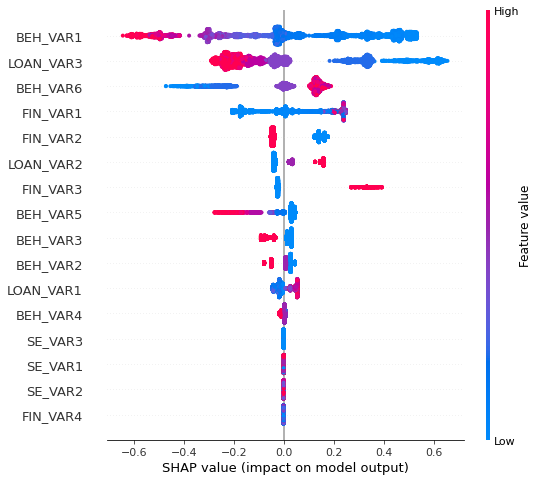

In [20]:
shap.summary_plot(shap_values, X_val)

# Performance on test set

In [21]:
rows_test = []
resultado = compute_metrics(X_test, Y_test, xgb_reweighted, best_threshold)
rows_test.append(resultado)

df_metricas_test = pd.DataFrame(rows_test, columns=['Threshold', 'TMO', 'approvalRate', 'Recall', 'Precision', 'FPR', 'FNR'])
df_metricas_test.head()

,Threshold,TMO,approvalRate,Recall,Precision,FPR,FNR
0,0.927273,0.051891,0.55868,0.594123,0.948109,0.267311,0.405877


# Fairness Metrics

In [22]:
metrics = {
    "N": lambda y_true, y_pred: len(y_true),
    "Default_rate": tmo,
    "Accuracy": accuracy_score,
    "Precision": precision_score,
    "Recall": recall_score,
    "Selection_rate": selection_rate,
    "FPR": false_positive_rate,
    "FNR": false_negative_rate,
    "Specificity": true_negative_rate
}

mf1 = MetricFrame(
    metrics=metrics,
    y_true= Y_test,
    y_pred=(prob_test > best_threshold),
    sensitive_features= PF1_test
)

mf2 = MetricFrame(
    metrics=metrics,
    y_true= Y_test,
    y_pred=(prob_test > best_threshold),
    sensitive_features= PF2_test
)

# Check the combination of features, this is called intersectional fairness, 
# it could happen that at group level the model is fair
# but when considering the combination of protected features we might detect bias
intersectional_fairness = pd.DataFrame({"PF1": PF1_test, "PF2": PF2_test})

mf12 = MetricFrame(
    metrics=metrics,
    y_true= Y_test,
    y_pred=(prob_test > best_threshold),
    sensitive_features= intersectional_fairness
)

Fairness Metrics grouping by Protected Feature 1

In [23]:
mf1.by_group.head()

,N,Default_rate,Accuracy,Precision,Recall,Selection_rate,FPR,FNR,Specificity
PF1,,,,,,,,,
0,2522,0.0458849,0.59199,0.954115,0.575571,0.544409,0.256098,0.424429,0.743902
1,3204,0.0564074,0.622659,0.943593,0.609049,0.569913,0.274667,0.390951,0.725333


In [24]:
mf1.ratio()

N                 0.787141
Default_rate      0.813455
Accuracy          0.950746
Precision         0.988971
Recall            0.945032
Selection_rate     0.95525
FPR               0.932394
FNR               0.921122
Specificity       0.975038
dtype: object

Fairness Metrics grouping by Protected Feature 2

In [25]:
mf2.by_group.head()

,N,Default_rate,Accuracy,Precision,Recall,Selection_rate,FPR,FNR,Specificity
PF2,,,,,,,,,
0,3484,0.0522317,0.639208,0.947768,0.635062,0.604478,0.322581,0.364938,0.677419
1,2242,0.0512351,0.562444,0.948765,0.528542,0.487511,0.2,0.471458,0.8


In [26]:
mf2.ratio()

N                 0.643513
Default_rate       0.98092
Accuracy          0.879908
Precision          0.99895
Recall            0.832269
Selection_rate      0.8065
FPR                   0.62
FNR               0.774063
Specificity       0.846774
dtype: object

Fairness Metrics grouping by the intersection of protected features

In [27]:
mf12.by_group.head()

N Default_rate  Accuracy Precision    Recall Selection_rate  \
PF1 PF2                                                                   
0   0    1609    0.0475185   0.61964  0.952482  0.614023       0.588564   
    1     913    0.0422535  0.543264  0.957746  0.505576       0.466594   
1   0    1875    0.0560828     0.656  0.943917  0.653524       0.618133   
    1    1329    0.0569715  0.575621  0.943028  0.544589       0.501881   

              FPR       FNR Specificity  
PF1 PF2                                  
0   0    0.321429  0.385977    0.678571  
    1    0.169811  0.494424    0.830189  
1   0    0.323383  0.346476    0.676617  
    1    0.218391  0.455411    0.781609

In [28]:
mf12.ratio()

N                 0.486933
Default_rate       0.74166
Accuracy          0.828146
Precision         0.984633
Recall            0.773615
Selection_rate    0.754843
FPR               0.525109
FNR               0.700766
Specificity       0.815016
dtype: object